# Stage 09 — Homework Starter Notebook

In the lecture, we learned how to create engineered features. Now it’s your turn to apply those ideas to your own project data.

In [8]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
import sys
sys.path.append('../..')  # 让 notebook 能找到仓库根目录下的 src/
from src.features import add_spend_income_ratio, add_rolling_spend_mean, add_region_frequency_encoding

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Example synthetic data (replace with your project dataset)
np.random.seed(0)
n = 100
df = pd.DataFrame({
    'income': np.random.normal(60000, 15000, n).astype(int),
    'monthly_spend': np.random.normal(2000, 600, n).astype(int),
    'credit_score': np.random.normal(680, 50, n).astype(int),
    'region': np.random.choice(['North', 'South', 'East', 'West'], n),
    'default_flag': np.random.choice([0, 1], n, p=[0.8, 0.2]),
})
df.head()

,income,monthly_spend,credit_score,region,default_flag
0,86460,3129,661,East,0
1,66002,1191,668,North,0
2,74681,1237,734,West,0
3,93613,2581,712,South,1
4,88013,1296,712,East,1


## Engineered features — one is worked below; add at least two more

At least one of yours must encode a categorical column. `region` is the categorical
column here; the lecture shows three ways to encode it (one-hot, label, frequency).

In [10]:
# Worked example 1 of 3 — keep it, or swap in columns of your own.
df['spend_income_ratio'] = df['monthly_spend'] / df['income']
# Write the rationale in the markdown cell below.

### Rationale for Feature 1
Explain why this feature may help a model. Reference your EDA.

In [11]:
# TODO: Add another feature
# Example: df['rolling_spend_mean'] = df['monthly_spend'].rolling(3).mean()
df = add_spend_income_ratio(df)
df.head()

,income,monthly_spend,credit_score,region,default_flag,spend_income_ratio
0,86460,3129,661,East,0,0.036190
1,66002,1191,668,North,0,0.018045
2,74681,1237,734,West,0,0.016564
3,93613,2581,712,South,1,0.027571
4,88013,1296,712,East,1,0.014725


### Rationale for Feature 2
Explain why this feature may help a model. Reference your EDA.

In [12]:
# TODO: Add a third feature. At least one of your three must ENCODE A CATEGORICAL
#   column - `region` is the one in this dataset.
#
#   The lecture shows three ways (section 'Categorical Encoding'):
#     one-hot     pd.get_dummies(df, columns=['region'])
#     label       LabelEncoder().fit_transform(df['region'])
#     frequency   df['region'].map(df['region'].value_counts(normalize=True))
#
#   Pick one and say WHY you picked it in the markdown cell below - the three are not
#   interchangeable, and that choice is the point of the exercise.

In [13]:
df = add_rolling_spend_mean(df)
df.head()

,income,monthly_spend,credit_score,region,default_flag,spend_income_ratio,rolling_spend_mean
0,86460,3129,661,East,0,0.036190,NaN
1,66002,1191,668,North,0,0.018045,NaN
2,74681,1237,734,West,0,0.016564,1852.333333
3,93613,2581,712,South,1,0.027571,1669.666667
4,88013,1296,712,East,1,0.014725,1704.666667


Feature 3

In [14]:
df = add_region_frequency_encoding(df)
df[['region', 'region_freq']].head()

,region,region_freq
0,East,0.28
1,North,0.22
2,West,0.22
3,South,0.28
4,East,0.28


### Rationale for Feature 3
Explain why this feature may help a model. Reference your EDA. If this is your
categorical encoding, say why you chose that encoding over the other two.

I chose frequency encoding over one-hot or label encoding for region:

I avoided label encoding because the regions (East/North/South/West) have no natural order. Encoding them as 0/1/2/3 would falsely imply that "South(3) > East(0)," which could mislead the model into learning a ranking that doesn't actually exist.
I avoided one-hot encoding as well — while it's usually the safe default for categorical features since it introduces no artificial ordering, it expands one column into four, which can bloat the feature space when there are many categories. Here the category count is small, so one-hot would also have worked, but I wanted to preserve the extra signal of "how common is this region in the data."
I chose frequency encoding because it avoids the false-ordering problem of label encoding while still encoding how frequently each region appears in the dataset. If a region's relative sample share is itself correlated with the outcome (e.g., an underrepresented region might represent a smaller or emerging market with different risk characteristics), this could give the model useful additional information.

spend_income_ratio   -0.036101
rolling_spend_mean   -0.009780
region_freq           0.033070
Name: default_flag, dtype: float64


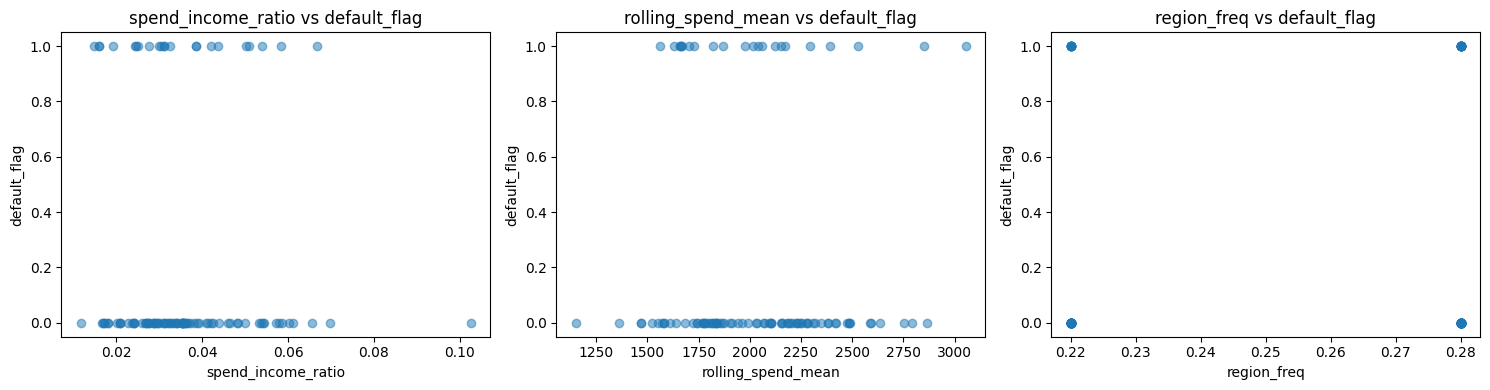

In [15]:
import matplotlib.pyplot as plt

# --- correlation check：3 new features vs default_flag ---
features_to_check = ['spend_income_ratio', 'rolling_spend_mean', 'region_freq']

correlations = df[features_to_check + ['default_flag']].corr()['default_flag'].drop('default_flag')
print(correlations)

# --- visualization ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feat in zip(axes, features_to_check):
    ax.scatter(df[feat], df['default_flag'], alpha=0.5)
    ax.set_xlabel(feat)
    ax.set_ylabel('default_flag')
    ax.set_title(f'{feat} vs default_flag')
plt.tight_layout()
plt.show()

All three engineered features show correlation coefficients close to 0 (between -0.04 and 0.03) with default_flag, and the scatter plots confirm no visible separation between the two outcome classes. This is expected since the synthetic dataset generates default_flag independently at random, so no feature — engineered or raw — should carry real predictive signal here. Once real project data replaces this synthetic set, correlation checks like this will actually help validate whether each feature's hypothesis holds up.